# Round 2: SVM with SMOTE (Synthetic Minority Over-sampling Technique)

**Goal**: Address class imbalance by oversampling minority classes using SMOTE before training the SVM.
**Method**: TF-IDF -> SMOTE -> Linear SVM

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

sns.set(style='whitegrid')
reports_dir = 'round2/reports'
os.makedirs(reports_dir, exist_ok=True)
print("Libraries imported.")

Libraries imported.


## 1. Load Data

In [2]:
train_df = pd.read_excel('round2/train.xlsx')
val_df = pd.read_excel('round2/val.xlsx')

X_train = train_df['cleaned_poem'].astype(str)
X_val = val_df['cleaned_poem'].astype(str)

# Primary Labels
y_train_p = train_df['primary_id']
y_val_p = val_df['primary_id']

# Secondary Labels
y_train_s = train_df['secondary_id']
y_val_s = val_df['secondary_id']

# Load Maps
with open('round2/label_maps.json', 'r') as f:
    maps = json.load(f)
p_map = {v: k for k, v in maps['primary_map'].items()}
s_map = {v: k for k, v in maps['secondary_map'].items()}

## 2. Feature Extraction (TF-IDF)

In [3]:
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=5, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
print(f"Feature Shape: {X_train_vec.shape}")

Feature Shape: (3299, 85597)


## 3. Train with SMOTE

In [4]:
def train_evaluate_smote(y_train, y_val, label_map, prefix):
    print(f"\nApplying SMOTE for {prefix}...")
    # k_neighbors=1 because some classes might have extremely few samples (e.g. 2-3)
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_res, y_res = smote.fit_resample(X_train_vec, y_train)
    print(f"Resampled Shape: {X_res.shape}")
    
    print(f"Training SVM for {prefix}...")
    model = LinearSVC(random_state=42, max_iter=2000) # No class_weight='balanced' needed as data is balanced
    model.fit(X_res, y_res)
    
    y_pred = model.predict(X_val_vec)
    
    acc = accuracy_score(y_val, y_pred)
    macro = f1_score(y_val, y_pred, average='macro')
    weighted = f1_score(y_val, y_pred, average='weighted')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro:.4f}")
    
    # Save Metrics
    metrics = {'accuracy': acc, 'macro_f1': macro, 'weighted_f1': weighted}
    with open(f'{reports_dir}/{prefix}_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=4)
        
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Purples', fmt='d')
    plt.title(f'{prefix} SVM+SMOTE Confusion Matrix')
    plt.savefig(f'{reports_dir}/{prefix}_confusion_matrix.png')
    plt.show()
    
    # Save Errors
    res = pd.DataFrame({'True': y_val, 'Pred': y_pred})
    res['True_Label'] = res['True'].map(label_map)
    res['Pred_Label'] = res['Pred'].map(label_map)
    errors = res[res['True'] != res['Pred']]
    errors.to_csv(f'{reports_dir}/{prefix}_errors.csv', index=False)

### 3.1 Primary Classification (SMOTE)


Applying SMOTE for primary_svm_smote...
Resampled Shape: (26450, 85597)
Training SVM for primary_svm_smote...
Accuracy: 0.3988
Macro F1: 0.2331


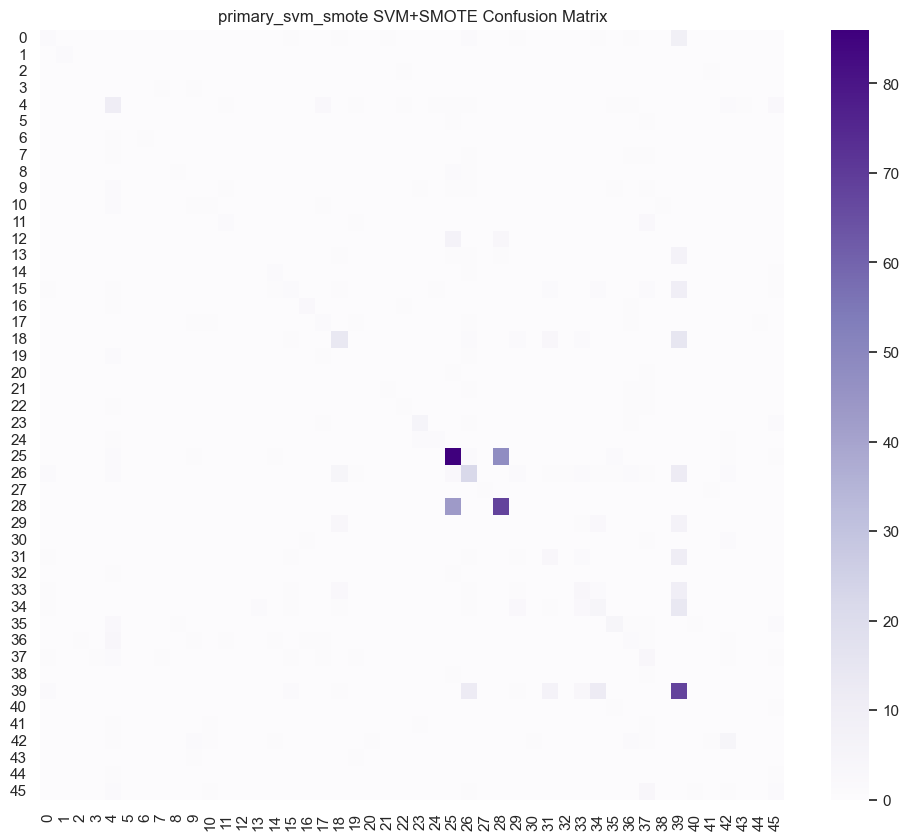

In [5]:
train_evaluate_smote(y_train_p, y_val_p, p_map, 'primary_svm_smote')

### 3.2 Secondary Classification (SMOTE)

In [ ]:
train_evaluate_smote(y_train_s, y_val_s, s_map, 'secondary_svm_smote')


Applying SMOTE for secondary_svm_smote...
Resampled Shape: (45155, 85597)
Training SVM for secondary_svm_smote...
